# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [1]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

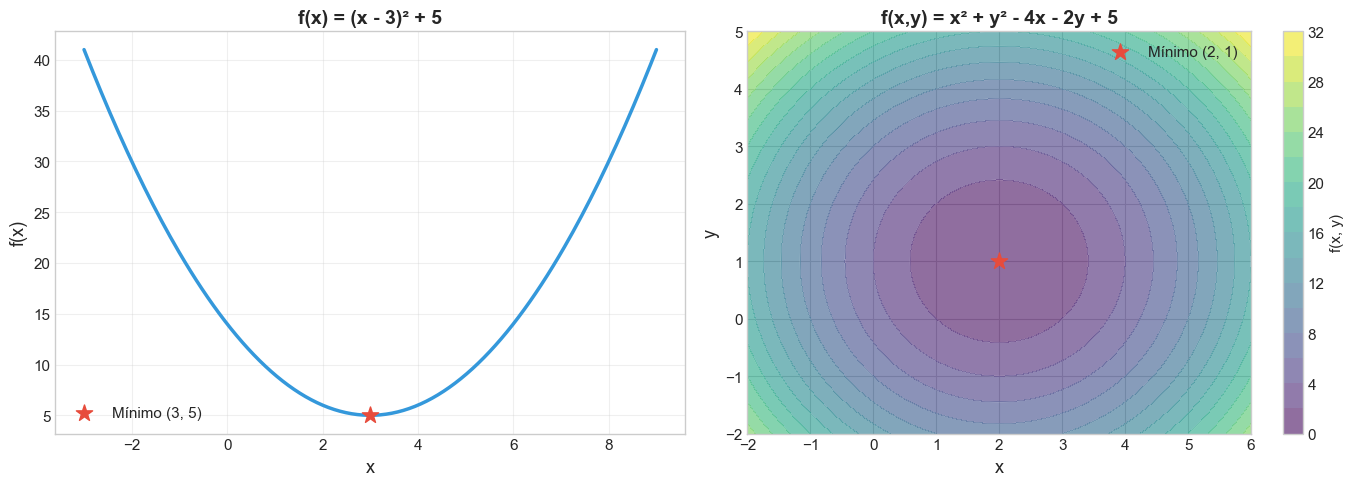

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [2]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [6]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    
    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa las variables:
    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False
    iteraciones = 0
    # 2. Loop principal (max_iter iteraciones):
    while not convergido and iteraciones < max_iter:
    #    a. Calcula el gradiente:
        g = df_1d(x_actual)
    #    b. Actualiza: 
        x_nuevo = x_actual - learning_rate * g
    #    c. Guarda en historial
        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))
    #    d. Verifica convergencia: si |x_nuevo - x_actual| < tolerancia -> convergido
        convergido = abs(x_nuevo - x_actual) < tolerancia
    #    e. Actualiza x_actual = x_nuevo
        x_actual = x_nuevo
        iteraciones += 1
    # 3. Retorna el diccionario con resultados
    return {
        "x_final": x_actual,
        "f_final": f_1d(x_actual),
        "historial_x": historial_x,
        "historial_f": historial_f,
        "iteraciones": iteraciones,
        "convergido": convergido
    }   

### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [7]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


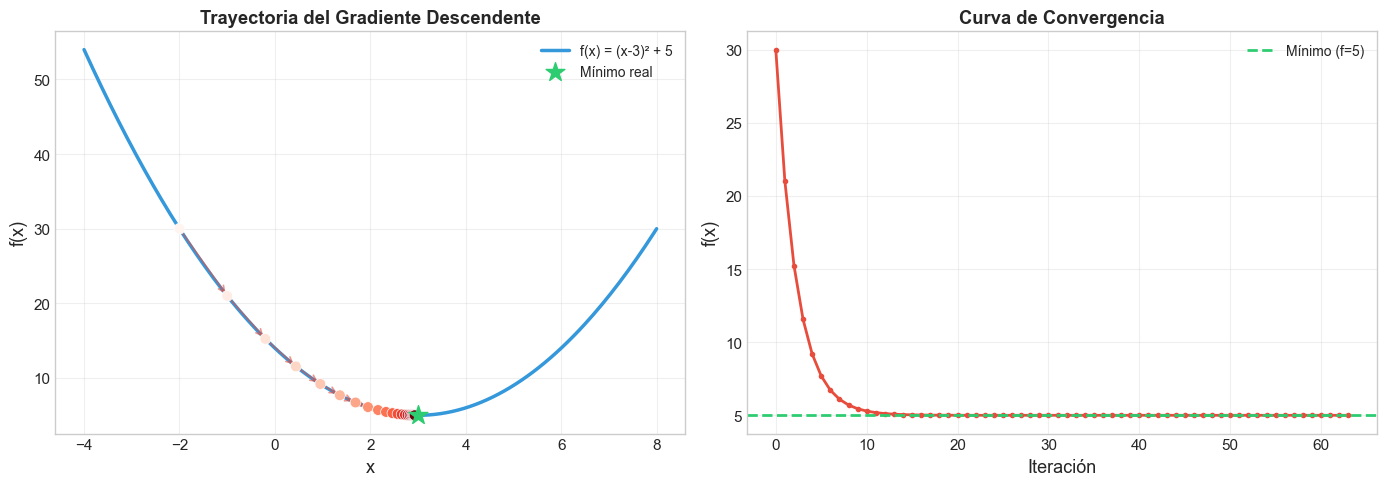

In [8]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [20]:
# ============================================================
# TU CODIGO AQUI: Ejecuta experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenar resultados
resultados_lr = []

# TU CODIGO: Para cada learning rate, ejecuta gradiente_descendente_1d
# y guarda los resultados en la lista resultados_lr
for lr in learning_rates_prueba:
    resultado = gradiente_descendente_1d(x_inicial_prueba, lr, max_iter_prueba)
    
    resultado['learning_rate'] = lr
    resultados_lr.append(resultado)

    # Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergi\u00f3':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

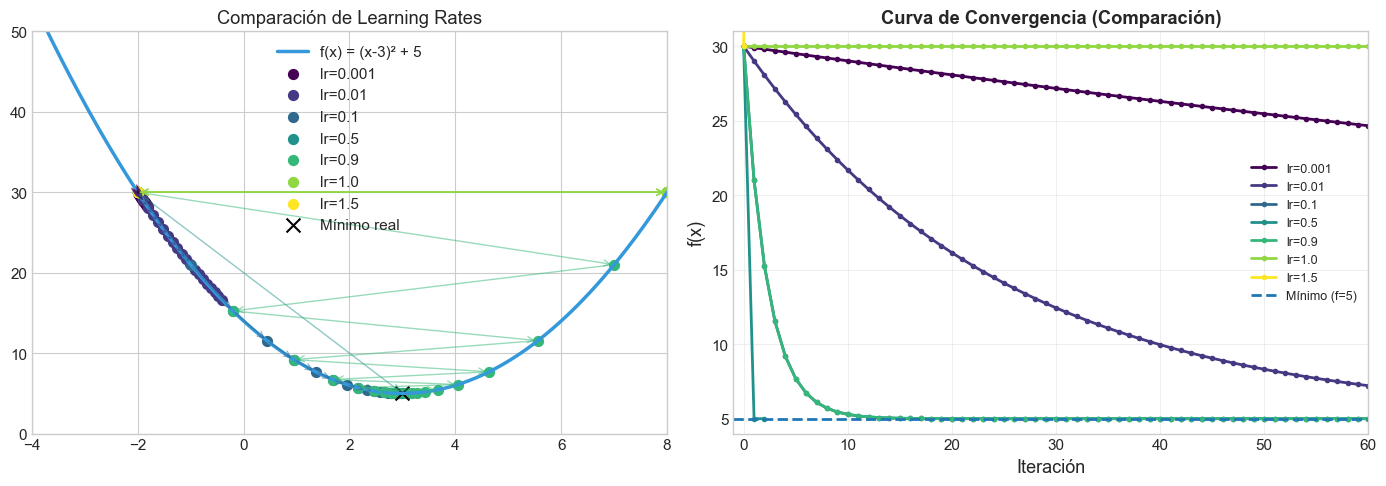

In [43]:
# ============================================================
# TU CODIGO AQUI: Grafica comparativa de learning rates
# ============================================================

# Crea dos graficas:
# 1. Trayectoria sobre f(x) para cada LR (con diferentes colores)
# 2. Curva de convergencia f(x) vs iteracion para cada LR

# Pista: usa fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Pista: usa colores distintos para cada LR

fig, axes = plt.subplots(1, 2, figsize=(14,5))
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color="#3498db", linewidth = 2.5, label = 'f(x) = (x-3)\u00b2 + 5')

colores = plt.cm.viridis(np.linspace(0, 1, len(resultados_lr)))

for i, res in enumerate(resultados_lr):
    hx = res['historial_x']
    hf = res['historial_f']
    lr = res['learning_rate']

    n_mostrar = min(20, len(hx))

    axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar],
                    color = colores[i],
                    s=50,
                    label = f'lr={lr}')
    
    for j in range(min(10, n_mostrar - 1)):
        axes[0].annotate('',
                            xy=(hx[j+1], hf[j+1]),
                            xytext=(hx[j], hf[j]),
                            arrowprops=dict(arrowstyle='->',
                                            color=colores[i],
                                            alpha=0.5))
    
axes[0].scatter([3], [5], marker='x', s=100, color = "black", label='Mínimo real')

axes[0].set_ylim(0, 50)
axes[0].set_xlim(-4, 8)
axes[0].set_title('Comparación de Learning Rates')
axes[0].legend()
axes[0].grid(True)

# Gráfica 2
colores = plt.cm.viridis(np.linspace(0, 1, len(resultados_lr)))
for i, res in enumerate(resultados_lr):
    hf = res['historial_f']
    lr = res['learning_rate']

    n_mostrar = min(100, len(hf))

    axes[1].plot(range(n_mostrar),
                 hf[:n_mostrar],
                 'o-',
                 linewidth = 2,
                 markersize = 3,
                 color = colores[i],
                 label = f'lr={lr}')
    
axes[1].axhline(y=5,
                linestyle='--',
                linewidth=2,
                label='Mínimo (f=5)')

axes[1].set_xlabel('Iteración', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia (Comparación)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(4, 31)
axes[1].set_xlim(-1, 60)

plt.tight_layout()
plt.show()

**Responde estas preguntas basandote en tus experimentos:**

1. **\u00bfQu\u00e9 pasa con un learning rate muy peque\u00f1o (0.001)?**
   - *Tu respuesta:* en algunos casos puede pasar que aunque se acerque no llegue al punto minimo por que realiza mas iteraciones de las que se estan permitiendo.

2. **\u00bfCu\u00e1l consideras el mejor learning rate y por qu\u00e9?**
   - *Tu respuesta:* en este caso considero que el de 0.5 es muy bueno

3. **\u00bfQu\u00e9 pasa con learning rates >= 1.0?**
   - *Tu respuesta:* al ser tan grandes en lugar de converger empiezan a diverger

4. **\u00bfPor qu\u00e9 un learning rate de exactamente 1.0 tiene un comportamiento especial para esta funci\u00f3n?**
   - *Tu respuesta:* en este caso con learning rate = 1 el paso es demasiado grande y justo en sustituido en la forma hace que entre en un ciclo infinito que oscilaran las x solo entre -2 y 8 y la f(x) siempre dara 30

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [50]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    
    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa:
    x_actual, y_actual = x_inicial, y_inicial
    #    - historiales vacios
    historial_x = []
    historial_y = []
    historial_f = []
    convergido = False
    iteraciones = 0
    
    # 2. Loop principal:
    while not convergido and iteraciones < max_iter:
    #    a. Calcula gradiente: 
        g = grad_2d(x_actual, y_actual)
    #    b. Actualiza ambos parametros:
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]
    #    c. Guarda en historiales
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))
    #    d. Verifica convergencia: si ||gradiente|| < tolerancia -> convergido
    #       (norma del gradiente: np.linalg.norm(g))
        convergido = np.linalg.norm(g) < tolerancia
    #    e. Actualiza x_actual, y_actual
        x_actual, y_actual = x_nuevo, y_nuevo
        iteraciones += 1
    # 3. Retorna diccionario con resultados
    return {
        "x_final": x_actual,
        "y_final": y_actual,
        "f_final": f_2d(x_actual, y_actual),
        "historial_x": historial_x,
        "historial_y": historial_y,
        "historial_f": historial_f,
        "iteraciones": iteraciones,
        "convergido": convergido,
        "learning_rate": learning_rate
    }

### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [51]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


<function matplotlib.pyplot.show(close=None, block=None)>

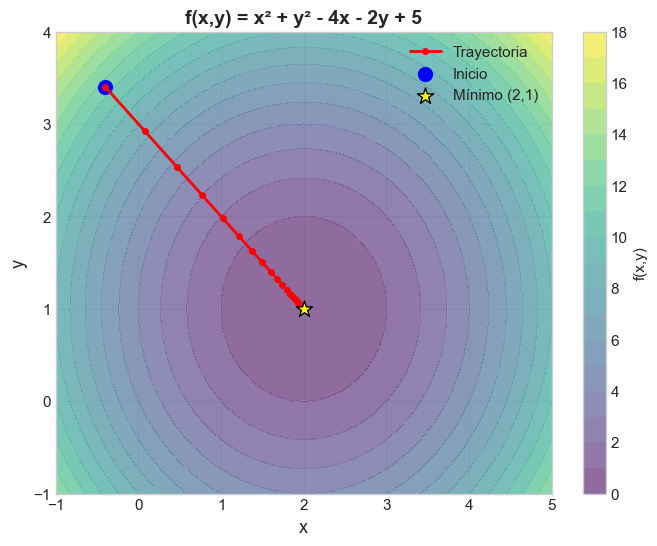

In [55]:
# ============================================================
# TU CODIGO AQUI: Visualizacion del gradiente descendente 2D
# ============================================================

# Crea una grafica con mapa de contornos que muestre:
# 1. Los contornos de la funcion f(x, y)
# 2. La trayectoria del gradiente descendente como puntos conectados
# 3. El punto de inicio marcado
# 4. El minimo real marcado con una estrella

# Pista: usa ax.contourf() para el fondo y ax.contour() para las lineas
# Pista: usa ax.plot(historial_x, historial_y, 'o-') para la trayectoria
x = np.linspace(-1, 5, 200)
y = np.linspace(-1, 4, 200)
X, Y = np.meshgrid(x, y)
Z = f_2d(X, Y)

hx = resultado_2d['historial_x']
hy = resultado_2d['historial_y']

fig, ax = plt.subplots(figsize=(8,6))

contour = ax.contourf(X, Y, Z, levels = 20, cmap = 'viridis', alpha = 0.6)
ax.contour(X, Y, Z, levels = 20, colors = 'white', alpha = 0.3, linewidths = 0.5)
plt.colorbar(contour, ax=ax, label='f(x,y)')
ax.plot(hx, hy, 'o-', color='red', linewidth=2, markersize=4, label='Trayectoria')
ax.scatter(hx[0], hy[0], color='blue', s=100, label='Inicio')
ax.scatter([2], [1], color = 'yellow', s = 150, marker = '*', zorder = 5, edgecolors='black', label = 'M\u00ednimo (2,1)')
ax.set_xlabel('x', fontsize = 13)
ax.set_ylabel('y', fontsize = 13)
ax.set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
ax.legend(fontsize = 11)
ax.grid(True, alpha=0.3)

plt.show


In [57]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

# Prueba al menos 3 puntos iniciales diferentes y compara los resultados
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

# TU CODIGO: ejecuta GD para cada punto inicial y muestra resultados

resultados = []

for (x0, y0) in puntos_iniciales:
    
    res = gradiente_descendente_2d(
        x_inicial=x0,
        y_inicial=y0,
        learning_rate=0.1,
        max_iter=100
    )
    
    resultados.append({
        "punto_inicial": (x0, y0),
        "x_final": res["x_final"],
        "y_final": res["y_final"],
        "f_final": res["f_final"],
        "iteraciones": res["iteraciones"],
        "convergido": res["convergido"]
    })

print("COMPARACIÓN DE PUNTOS INICIALES")
print("="*60)
print(f"{'Inicio':>15} {'(x,y) final':>20} {'f(x,y)':>10} {'Iter':>8} {'Conv':>8}")
print("-"*60)

for r in resultados:
    print(f"{str(r['punto_inicial']):>15} "
          f"{(round(r['x_final'],4), round(r['y_final'],4))!s:>20} "
          f"{r['f_final']:>10.4f} "
          f"{r['iteraciones']:>8} "
          f"{str(r['convergido']):>8}")

COMPARACIÓN DE PUNTOS INICIALES
         Inicio          (x,y) final     f(x,y)     Iter     Conv
------------------------------------------------------------
    (-1.0, 4.0) (np.float64(2.0), np.float64(1.0))     0.0000       73     True
    (5.0, -1.0) (np.float64(2.0), np.float64(1.0))     0.0000       72     True
     (0.0, 0.0) (np.float64(2.0), np.float64(1.0))     0.0000       70     True


---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [59]:
# ============================================================
# TU CODIGO AQUI: Genera el DataFrame con todos los experimentos
# ============================================================

# 1. Ejecuta TODOS los experimentos:
#    - 1D: learning_rates [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
#           desde x=-2.0
#    - 2D: learning_rates [0.001, 0.01, 0.1, 0.5]
#           desde (-1, 4), (5, -1), (0, 0)

# 2. Crea el DataFrame

# 3. Guardalo como CSV

# df_experimentos = pd.DataFrame(...)
# df_experimentos.to_csv('experimentos_gd.csv', index=False)

learning_rates_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_1d = -2.0

learning_rates_2d = [0.001, 0.01, 0.1, 0.5]
puntos_iniciales_2d = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0)
]

registros = []

for lr in learning_rates_1d:
    res = gradiente_descendente_1d(
        x_inicial=x_inicial_1d,
        learning_rate=lr,
        max_iter=200
    )
    
    registros.append({
        "tipo": "1D",
        "learning_rate": lr,
        "x_inicial": x_inicial_1d,
        "y_inicial": None,
        "x_final": res["x_final"],
        "y_final": None,
        "f_final": res["f_final"],
        "iteraciones": res["iteraciones"],
        "convergido": res["convergido"]
    })

for (x0, y0) in puntos_iniciales_2d:
    for lr in learning_rates_2d:
        
        res = gradiente_descendente_2d(
            x_inicial=x0,
            y_inicial=y0,
            learning_rate=lr,
            max_iter=100
        )
        
        registros.append({
            "tipo": "2D",
            "learning_rate": lr,
            "x_inicial": x0,
            "y_inicial": y0,
            "x_final": res["x_final"],
            "y_final": res["y_final"],
            "f_final": res["f_final"],
            "iteraciones": res["iteraciones"],
            "convergido": res["convergido"]
        })

df_experimentos = pd.DataFrame(registros)

df_experimentos.to_csv("experimentos_gd.csv", index=False)

print("Archivo generado: experimentos_gd.csv")
df_experimentos.head()

Archivo generado: experimentos_gd.csv


,tipo,learning_rate,x_inicial,y_inicial,x_final,y_final,f_final,iteraciones,convergido
0,1D,0.001,-2.0,NaN,-0.350258,NaN,16.224229,200,False
1,1D,0.010,-2.0,NaN,2.912060,NaN,5.007733,200,False
2,1D,0.100,-2.0,NaN,2.999996,NaN,5.000000,63,True
3,1D,0.500,-2.0,NaN,3.000000,NaN,5.000000,2,True
4,1D,0.900,-2.0,NaN,3.000000,NaN,5.000000,73,True


In [60]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
tipo  learning_rate  x_inicial  y_inicial       x_final   y_final       f_final  iteraciones  convergido
  1D          0.001       -2.0        NaN -3.502581e-01       NaN  1.622423e+01          200       False
  1D          0.010       -2.0        NaN  2.912060e+00       NaN  5.007733e+00          200       False
  1D          0.100       -2.0        NaN  2.999996e+00       NaN  5.000000e+00           63        True
  1D          0.500       -2.0        NaN  3.000000e+00       NaN  5.000000e+00            2        True
  1D          0.900       -2.0        NaN  3.000000e+00       NaN  5.000000e+00           73        True
  1D          1.000       -2.0        NaN -2.000000e+00       NaN  3.000000e+01          200       False
  1D          1.500       -2.0        NaN -8.034690e+60       NaN 6.455625e+121          200       False
  2D          0.001       -1.0        4.0 -4.557004e-01  3.455700  1.206093e+01          100       False
  2D          0.010  

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **\u00bfCu\u00e1l es el rango de learning rates que funciona bien para estas funciones?**
   - *Tu respuesta:* entre 0.5 y 0.1

2. **\u00bfEl punto inicial afecta si el algoritmo converge? \u00bfAfecta cu\u00e1ntas iteraciones necesita?**
   - *Tu respuesta:* afecta si esta muy lejos ya que puede hacer que ocupe mas iteraciones, ademas en funciones con minimos locales tambien afecta aunque no es el caso en este.

3. **\u00bfQu\u00e9 pasar\u00eda si la funci\u00f3n tuviera m\u00faltiples m\u00ednimos locales? (piensa en una funci\u00f3n como `sin(x) + x\u00b2/10`)**
   - *Tu respuesta:* el minimo que encuentre dependera de tu punto inicial

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la funci\u00f3n de costo es como `f(x,y)`. \u00bfPor qu\u00e9 es importante elegir bien el learning rate al entrenar?**
   - *Tu respuesta:* importa ya que es el que controla el tamaño de los pasos, pasos muy grandes puedes salirte del rango y no converger, muy chico es seguro que llegas pero puedesusar muchisimas iteraciones y agrandar el costp

5. **\u00bfQu\u00e9 ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - *Tu respuesta:* es mas eficiente ya que usa los datos para saber a donde moverse ademas de que con un buen learning rate puedes hacerlo muy facil

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [61]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [68]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    
    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch
    
    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa w = 0, b = 0
    # 2. Para cada epoch:
    #    a. Mezcla los indices aleatoriamente
    #    b. Para cada mini-batch:
    #       - Selecciona batch_size muestras
    #       - Calcula prediccion: y_pred = w * X_batch + b
    #       - Calcula error: error = y_batch - y_pred
    #       - Calcula gradientes:
    #           dw = -2/batch_size * sum(error * X_batch)
    #           db = -2/batch_size * sum(error)
    #       - Actualiza: w = w - lr * dw, b = b - lr * db
    #    c. Calcula MSE del epoch completo y guarda en historial
    w = 0
    b = 0
    n = len(X)
    mse_history = []
    w_history = []
    b_history = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(0, n, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            y_pred = w * X_batch + b
            
            error = y_batch - y_pred
            
            dw = -2/len(X_batch) * np.sum(error * X_batch)
            db = -2/len(X_batch) * np.sum(error)
            
            w = w - learning_rate * dw
            b = b - learning_rate * db
        
        y_pred_full = w * X + b
        mse = np.mean((y - y_pred_full)**2)
        mse_history.append(mse)
        w_history.append(w)
        b_history.append(b)
    
    return w, b, mse_history, w_history, b_history

In [69]:
print(X_sgd[:10])
print(np.mean(X_sgd), np.std(X_sgd))

[-0.37213971  1.58661523  0.84305607  0.38977043 -1.11502273 -1.11510473
 -1.44796149  1.2992203   0.39812162  0.76173329]
-1.887379141862766e-16 1.0


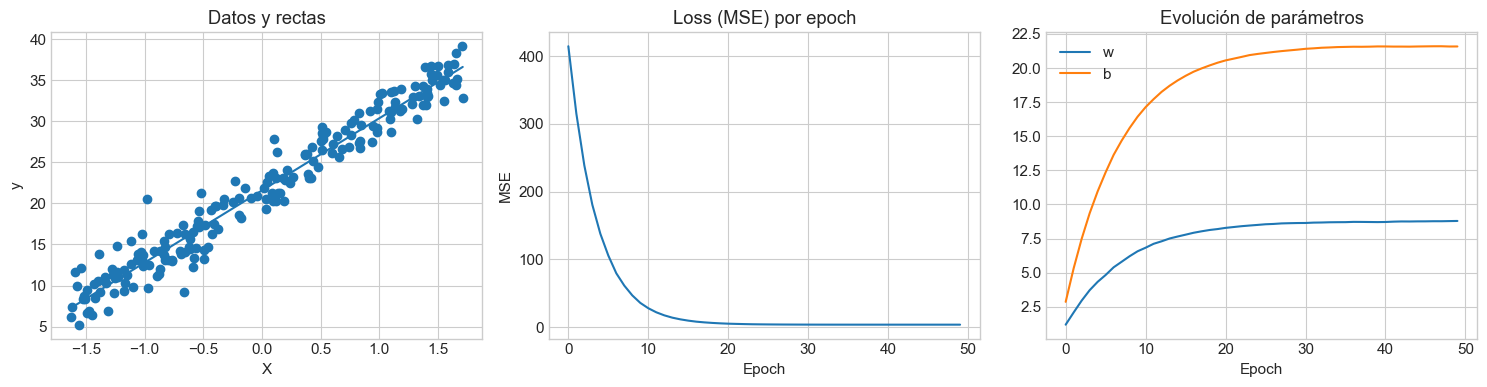

In [70]:
# Ejecuta SGD y visualiza resultados

resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

# TU CODIGO: Crea graficas comparando:
# 1. Datos + linea aprendida por SGD vs linea real
# 2. Curva de loss por epoch
# 3. Evolucion de w y b por epoch

w, b, mse_history, w_history, b_history = resultado_sgd

def graficas_sgd(X, y, w, b, mse_history, w_history, b_history, w_real=None, b_real=None):
    
    X_sorted = np.sort(X)
    y_pred_line = w * X_sorted + b
    
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.scatter(X, y)
    plt.plot(X_sorted, y_pred_line)
    
    if w_real is not None and b_real is not None:
        y_real = w_real * X_sorted + b_real
        plt.plot(X_sorted, y_real)
    
    plt.title("Datos y rectas")
    plt.xlabel("X")
    plt.ylabel("y")
    
    plt.subplot(1, 3, 2)
    plt.plot(mse_history)
    plt.title("Loss (MSE) por epoch")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")

    plt.subplot(1, 3, 3)
    plt.plot(w_history, label="w")
    plt.plot(b_history, label="b")
    plt.legend()
    plt.title("Evolución de parámetros")
    plt.xlabel("Epoch")
    
    plt.tight_layout()
    plt.show()

X_sgd = (X_sgd - np.mean(X_sgd)) / np.std(X_sgd)
graficas_sgd(X_sgd, y_sgd, w, b, mse_history, w_history, b_history)

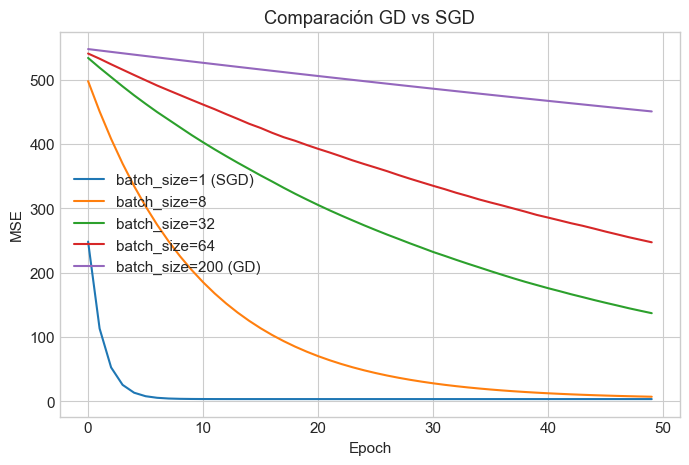

In [73]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes

# batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro

# TU CODIGO: ejecuta para cada batch_size y compara convergencia

batch_sizes = [1, 8, 32, 64, len(X_sgd)]

resultados = {}

for bs in batch_sizes:
    w, b, mse_hist, _, _ = sgd_regresion_lineal(
        X_sgd, y_sgd,
        learning_rate=0.001,
        epochs=50,
        batch_size=bs
    )
    
    resultados[bs] = mse_hist

plt.figure(figsize=(8,5))

for bs, mse_hist in resultados.items():
    label = f"batch_size={bs}"
    
    if bs == 1:
        label += " (SGD)"
    elif bs == len(X_sgd):
        label += " (GD)"
    
    plt.plot(mse_hist, label=label)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Comparación GD vs SGD")
plt.legend()
plt.show()


**Preguntas Bonus:**

1. **\u00bfQu\u00e9 diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - *Tu respuesta:* 

2. **\u00bfCu\u00e1l batch_size te dio los mejores resultados? \u00bfPor qu\u00e9?**
   - *Tu respuesta:*

3. **\u00bfPor qu\u00e9 la curva de loss de SGD es m\u00e1s ruidosa que la de GD?**
   - *Tu respuesta:*

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_